In [1]:
using DifferentialEquations
using Graphs
using ComponentArrays
using LinearAlgebra
using Statistics
using Plots

using Revise

include("synchrony.jl")

using .Synchrony



forward (increasing K)...
backward (decreasing K)...


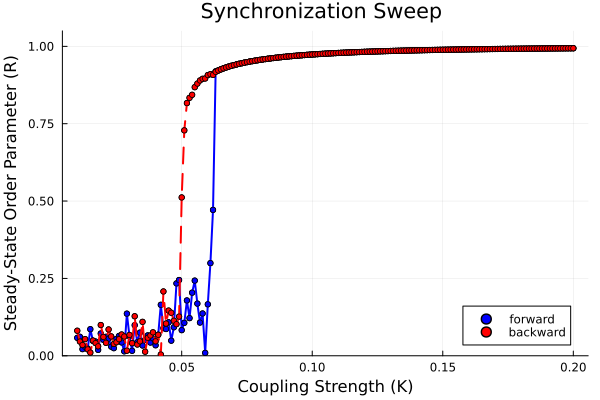

In [2]:
function scale_free_kuramoto_model_hysteresis_sweep_forward_backward(N, d)
    g = barabasi_albert(N, d)
    vs = sort([i for i in vertices(g)])
    degrees = Dict(i => degree(g, i) for i in vs)
    models = [Kuramoto(degrees[v]/2/maximum(degree(g))* 2π ) for v in vs]

    tspan = (0.0, 50.0) 

    # forward and backward sweep range
    K_forward = 0.01:0.001:0.2
    K_backward = reverse(K_forward)
    R_forward = Float64[]
    R_backward = Float64[]

    println("forward (increasing K)...")
    u0_forward = rand(N) * 2π # initialrandom phases

    for K in K_forward
        network = DynamicalNetwork(g, models, K)
        prob = ODEProblem(network_dynamics!, u0_forward, tspan, network)
        sol = solve(prob, Tsit5(), reltol=1e-4, abstol=1e-4, save_everystep=false)
        
        # calculate R
        final_phases = sol.u[end]
        push!(R_forward, abs(sum(exp.(im .* final_phases))) / N)
        
        u0_forward = rem2pi.(final_phases, RoundDown) # the evolved state is new initial state
    end

    println("backward (decreasing K)...")
    # starting from highly synchronized phases from the forward sweep
    u0_backward = copy(u0_forward) 

    for K in K_backward
        network = DynamicalNetwork(g, models, K)
        prob = ODEProblem(network_dynamics!, u0_backward, tspan, network)
        sol = solve(prob, Tsit5(), reltol=1e-4, abstol=1e-4, save_everystep=false)
        
        final_phases = sol.u[end]
        push!(R_backward, abs(sum(exp.(im .* final_phases))) / N)
        
        u0_backward = rem2pi.(final_phases, RoundDown)
    end

    # reverse R_backwards to match R_forward K values
    R_backward = reverse(R_backward)

    # sweep plots
    plot(K_forward, R_forward, 
        seriestype=:scatterpath, markersize=3, linewidth=2,
        label="forward", color=:blue, legend=:bottomright)

    plot!(K_forward, R_backward, 
        seriestype=:scatterpath, markersize=3, linewidth=2, linestyle=:dash,
        label="backward", color=:red,
        xlabel="Coupling Strength (K)", 
        ylabel="Steady-State Order Parameter (R)", 
        title="Synchronization Sweep ",
        ylims=(0, 1.05), grid=true, legend=:bottomright)
end


scale_free_kuramoto_model_hysteresis_sweep_forward_backward(400, 5)